In [1]:
import numpy as np
import pandas as pd
import random
from random import randint
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

In [2]:
def weighted_median_general(data, weights):
    # Pair each data point with its weight and sort by data point
    data_weights = sorted(zip(data, weights))
    
    total_weight = sum(weights)
    cumulative_weight = 0.0
    
    for value, weight in data_weights:
        cumulative_weight += weight
        if cumulative_weight >= total_weight / 2.0:
            return value
    
    # If for some reason the loop completes without returning, return the last value
    return data[-1]
def weighted_median(data, weights):
    max_n = 1005
    m = len(data)
    cc = [0.0]*(max_n+1)
    for i in range(m):
        if data[i]>max_n:
            cc[max_n] += weights[i]
        else:
            cc[data[i]] += weights[i]
    w = 0
    tot_weight = sum(cc) * 0.5
    for i in range(max_n+1):
        w += cc[i]
        if w>tot_weight:
            return i
def plot_series(arr):
    plt.plot(arr)
    plt.show()
def plot_dist(arr):
    plt.hist(arr, bins=np.arange(min(arr), max(arr)+1), edgecolor='black')
    plt.show()
fac_max = 155
fac=[1]
for i in range(1,fac_max):
    fac.append(fac[-1]*i)
ffac = np.array(fac).astype(float)
binom_mat = np.zeros((fac_max,fac_max))
for i in range(fac_max):
    for j in range(fac_max):
        binom_mat[i,j] = fac[i]/(fac[j]*fac[i-j])
def get_fac(n):
    #return fac[n]
    return ffac[n]
def binom(n,m):
    #return (fac[n])//(fac[m]*fac[n-m])
    #return get_fac(n)/(get_fac(m)*get_fac(n-m))
    return binom_mat[n,m]
def find_list_median(numbers):
    sorted_numbers = sorted(numbers)
    n = len(sorted_numbers)
    mid = n // 2
    return (sorted_numbers[mid] + sorted_numbers[~mid]) / 2
def apply_bounds(value, lower_bound, upper_bound):
    return max(lower_bound, min(value, upper_bound))
def get_game_value():
    di=100
    while di>10 or bo>12 or bo<2:
        t1=randint(2,22)
        t2=randint(2,int( (100-t1)/4 + 2 )  )
        t3=randint(1,int( (100-t1-t2)/3 + 1 )  )
        t4=randint(0,int( (100-t1-t2-t3)/2  )  )
        t5=randint(0,int( (100-t1-t2-t3-t4)  )  )
        di,bo,g,s,br = sorted([t1,t2,t3,t4,t5])
    return ([br,s,g,bo,di])
def get_yield_by_picked(picked):
    return ( (picked[0]*2+picked[1]*5+picked[2]*10)*(2**picked[4]) )  
def sample_picked_once(game_value):
    left = game_value.copy()
    picked = [0]*5
    while(sum(left)>=1 and picked[3]<2):
        now = random.choices(list(range(5)), left, k=1)[0]
        left[now] -= 1
        picked[now] += 1
    return picked
def sample_yield_once(game_value):
    picked = sample_picked_once(game_value)
    return get_yield_by_picked(picked)
def sample_median(game_value):
    lst = []
    for i in range(1000000):
        lst.append( sample_yield_once(game_value) )
    return find_list_median(lst)
def count_realization(type_value,game_value):
    type_sum = sum(type_value)
    uni_sum = sum(game_value)
    res = 1.0
    for i in range(5):
        res=res*binom(game_value[i],type_value[i])
    res=res/binom(uni_sum,type_sum)
    res=res*2.0/type_sum
    return res
def get_ywlst(game_value):
    # lack  * 2.0 * binom(game_value[3],2)
    res = []
    uni_sum = sum(game_value)
    type_sum = 2
    y = 0
    for br in range(game_value[0]+1):
        y = y + br*2
        type_sum = type_sum + br
        wbr = binom(game_value[0],br)
        for s in range(game_value[1]+1):
            y = y + s*5
            type_sum = type_sum + s
            ws = wbr * binom(game_value[1],s)
            for g in range(game_value[2]+1):
                y = y + g*10
                type_sum = type_sum + g
                wg = ws * binom(game_value[2],g)
                yy = y
                for di in range(game_value[4]+1):
                    type_sum = type_sum + di
                    now = [br,s,g,2,di]
                    w =  wg * binom(game_value[4],di) / ( binom(uni_sum,type_sum)*type_sum )
                    res.append((yy,w))
                    yy = yy*2
                    type_sum = type_sum - di
                y = y - g*10
                type_sum = type_sum -g
            y = y - s*5
            type_sum = type_sum - s
        y = y - br*2
        type_sum = type_sum - br
    return res
def get_ywlst_oldversion(game_value):
    res = []
    for br in range(game_value[0]+1):
        for s in range(game_value[1]+1):
            for g in range(game_value[2]+1):
                for di in range(game_value[4]+1):
                    now = [br,s,g,2,di]
                    w = count_realization(now,game_value)
                    y = get_yield_by_picked(now)
                    res.append((y,w))
    return res
def get_median_by_ywlst(game_value):
    ywlst = get_ywlst(game_value)
    #sorted_ywlist = sorted(ywlst)
    list_of_tuple = tuple(map(list, zip(*ywlst)))
    ylst = list_of_tuple[0]
    wlst = list_of_tuple[1]
    return weighted_median(ylst,wlst)

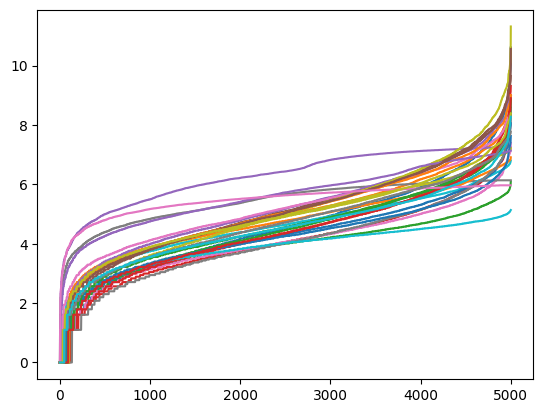

[]
[]


In [3]:
game_value = get_game_value()
arr = []
medlst = []
for i in range(30):
    arr = []
    game_value = get_game_value()
    #med = get_median_by_ywlst(game_value)
    #medlst.append(med)
    #print(game_value)
    for j in range(5000):
        picked = sample_picked_once(game_value)
        arr.append((picked[0]*2 + picked[1]*5 + picked[2]*10)*(2**picked[4]))
    arr = np.array(arr)
    #arr[arr>500]=500
    #arr = arr/500.0
    #arr = arr**0.5
    arr=np.log(arr+1)
    #arr=1.0/(1.0+np.exp(  (arr-np.log(100))*1.0  ))
    #arr[arr>6]=5.0+np.log(arr[arr>6]-5.0)
    #arr[arr<4]=5.0-np.log(5.0-arr[arr<4])
    #arr[arr<3]=3
    #arr[arr>6.2]=6.2
    #e^4.6=100
    arr = sorted(arr)
    plt.plot(arr)
plt.show()
ar = np.array(medlst)
print(ar)
print(np.log(ar))

#plot_series(arr)
#plot_dist(arr)

In [34]:
def get_penalty(fun_lst,fun_name=None):
    m = len(fun_lst)
    n=7
    sv = {}
    for i in range(m):
        for j in range(3):
            sv[(i,j)]=0
    penal = [0] * m
    pel = np.zeros(30)
    for i in range(3000):
        game_value = get_game_value()
        med = get_median_by_ywlst(game_value)
        last_yield = -1
        last_total_bid = -1
        for j in range(30):
            bid = []
            for k in range(m):
                now, sv[(k,0)] , sv[(k,1)], sv[(k,2)] = fun_lst[k]( last_total_bid, last_yield, sv[(k,0)] , sv[(k,1)], sv[(k,2)]  )
                if now<0:
                    now=0
                bid.append(now)
            last_yield = sample_yield_once(game_value)
            last_total_bid = sum(bid)
            for k in range(m):
                penal[k] = penal[k] + abs(med - bid[k]*n)
            pel[j] = pel[j] + abs(med - bid[0]*n)
        if i%50==49:
            print(penal)
            if fun_name is not None:
                print(fun_name[penal.index(min(penal))])
            plot_series(pel)
def Simulation(player_lst, num=600, vnum=200):
    n = len(player_lst)
    sv = {}
    for i in range(n):
        for j in range(3):
            sv[(i,j)]=0
    score = np.zeros(7)
    penal = np.zeros(7)
    pel = np.zeros(150)
    for i in range(num):
        game_value = get_game_value()
        med = get_median_by_ywlst(game_value)
        last_yield = -1
        last_total_bid = -1
        for j in range(150):
            bid = []
            for k in range(n):
                now, sv[(k,0)] , sv[(k,1)], sv[(k,2)] = player_lst[k]( last_total_bid, last_yield, sv[(k,0)] , sv[(k,1)], sv[(k,2)]  )
                if now<0:
                    now=0
                bid.append(now)
            bid = np.array(bid)
            last_yield = sample_yield_once(game_value)
            bid_ave = np.average(bid)
            last_total_bid = int(bid_ave+0.5)
            if last_total_bid<=last_yield:
                score = score+bid
            else:
                score = score-bid+bid_ave
            penal = penal + np.abs(last_yield - bid)
            pel[j] = pel[j] + np.abs(last_yield - med)
        if i%vnum==vnum-1:
            print(np.array(score)/(i+1)/150.0/7.0)
            print(np.array(penal)/(i+1)/150.0/7.0)
            plot_series(np.array(pel)/(i+1)/7.0)

In [17]:
def low_up_fun(low,up):
    def f(last_total_bid, last_yield, s1, s2, s3):
        if last_yield == -1:
            s1=5
            s2=5.0*np.log(101.0)
        else:
            s1 = s1 + 1
            now = np.log( last_yield+1 )
            if now<low:
                now=low
            if now>up:
                now=up
            s2 = s2 + now
        bid = int((np.exp(s2/s1)-1.0) + 0.5)
        return (bid,s1,s2,s3)
    return f

[8.77840544 8.78379592 8.77629116 8.77973878 8.77792925 8.79078639
 8.33259592]
[25.40822857 25.4067619  25.4107619  25.40769524 25.40904762 25.40278095
 26.50535238]


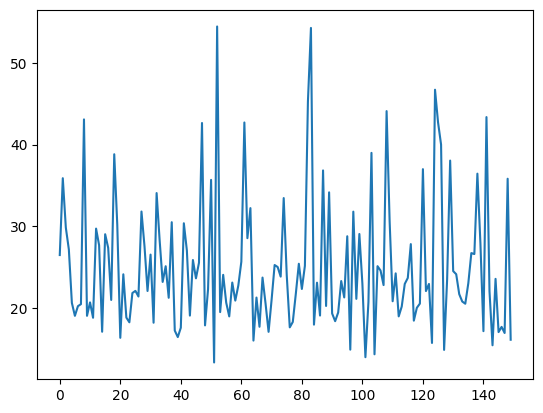

[8.95750204 8.96030204 8.95469252 8.95814966 8.95674014 8.96648299
 8.46343537]
[28.48334286 28.48442857 28.48706667 28.4833619  28.48452381 28.47925714
 29.59634286]


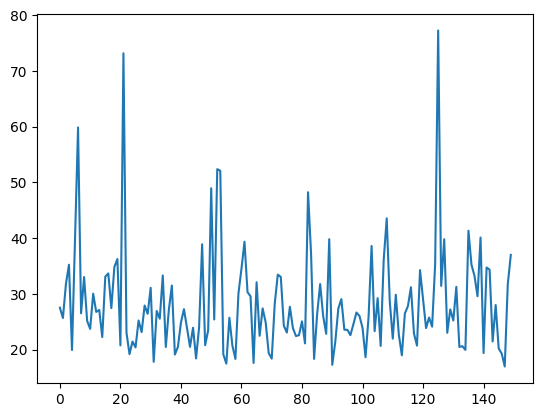

[8.91640544 8.9203356  8.91402449 8.91733878 8.91579592 8.92617052
 8.51789751]
[29.47179683 29.47349206 29.47493968 29.47199365 29.47297778 29.46896508
 30.5076254 ]


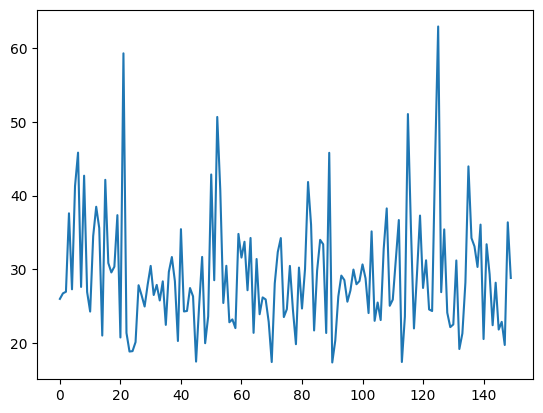

[8.54085238 8.54451905 8.5385381  8.54201429 8.54027143 8.55141905
 8.20629524]
[28.97101429 28.97251905 28.9741     28.9709381  28.97214762 28.96721905
 29.85655238]


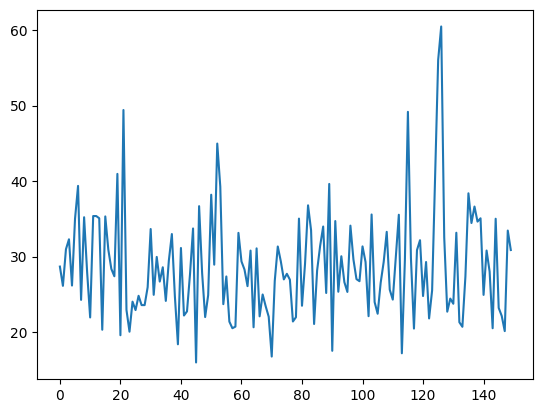

[8.74920762 8.7527619  8.74709714 8.75030476 8.74873524 8.75887619
 8.3566781 ]
[29.28574476 29.28800381 29.28856381 29.2860419  29.2868419  29.28345143
 30.28357714]


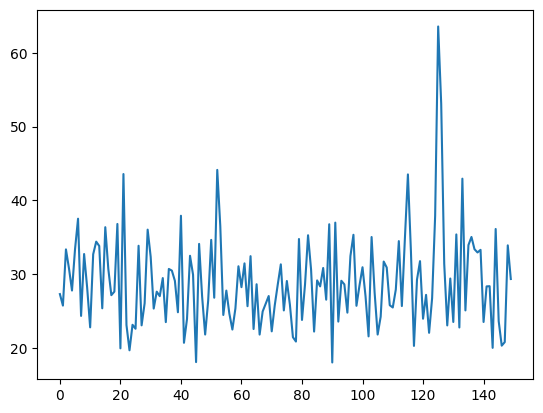

[8.85382086 8.85771927 8.8515034  8.85519229 8.85342086 8.86474467
 8.39523991]
[29.40903492 29.41065397 29.41194286 29.40905397 29.4100254  29.40552698
 30.49030794]


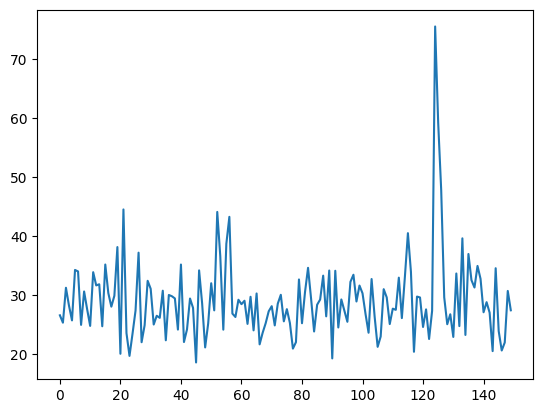

[8.6223102  8.62728163 8.61952653 8.62397007 8.6219619  8.63573878
 8.17672653]
[29.10390748 29.10441633 29.10721905 29.10365714 29.10484898 29.09849524
 30.16231293]


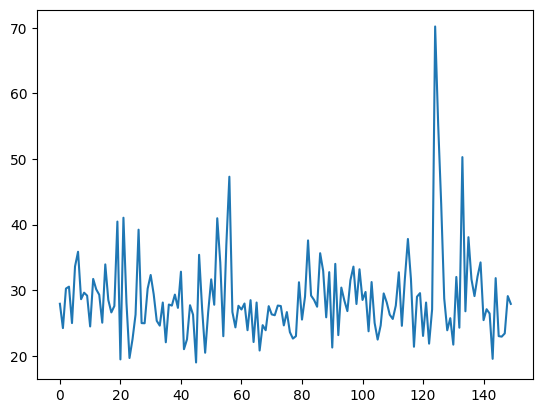

[8.7565619  8.76081667 8.75374524 8.75811667 8.75605952 8.76973095
 8.25012381]
[29.69495    29.6962381  29.6982619  29.69475714 29.69601429 29.68978571
 30.86647857]


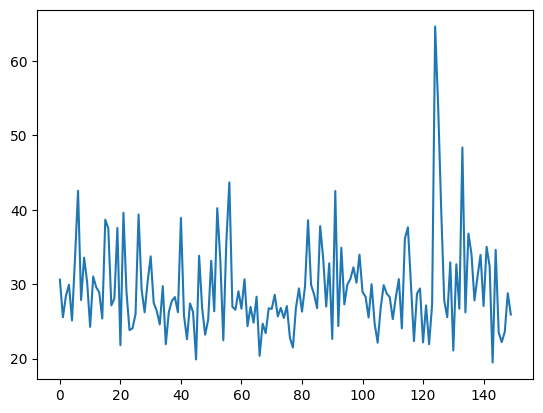

[8.6876517  8.69271202 8.68487075 8.6895226  8.68723265 8.70173636
 8.19426757]
[29.82609735 29.82668783 29.82942011 29.82562751 29.82711323 29.82000847
 30.95259894]


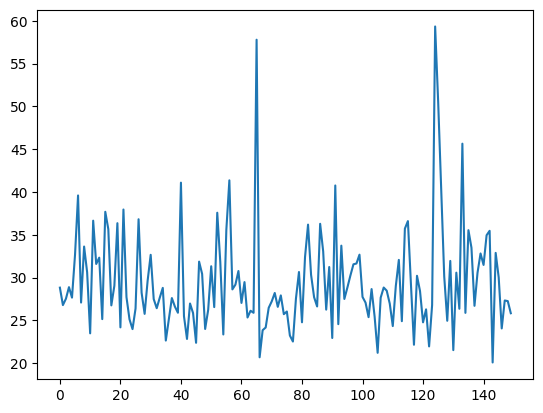

KeyboardInterrupt: 

In [35]:
#player_lst = [st2] + [st3] + [st4] + [naive_strategy] * 4
random.seed(342)
player_lst = [low_up_fun(3.15,7.4)] +[low_up_fun(3.0,8.0)]+[low_up_fun(3.2,7.4)]+[low_up_fun(3.1,7.55)] +\
                 [low_up_fun(3.15,7.45)] + [low_up_fun(2.8,8.0)]  + [naive_strategy]
#player_lst = [naive_strategy]*7
Simulation(player_lst,num=600, vnum=50)

In [24]:
def naive_strategy( last_total_bid, last_yield, s1, s2, s3):
    if last_yield == -1:
        bid = 100
    elif last_total_bid<=last_yield:
        bid = s1+1
    else:
        bid = s1-1
    if bid<0:
        bid = 0
    s1 = bid
    return (bid,s1,s2,s3)